In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer




In [2]:
file_path = '..\\Data\\taxi_trip_pricing.csv'

dataset_df = pd.read_csv(file_path)
dataset_df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [3]:
dataset_df = dataset_df.dropna(subset=['Trip_Price']).copy()
dataset_df.shape

(951, 11)

Rows with missing Trip_Price were removed because this is the target variable for regression. 
Imputing target values would introduce artificial information and reduce model accuracy.
Only 4.9% of rows were removed (49 rows total), which is small enough to avoid negatively impacting the dataset.


In [4]:
X = dataset_df.copy().drop('Trip_Price', axis=1)
y = dataset_df['Trip_Price']

In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
X_test.shape

(760, 10)


(191, 10)

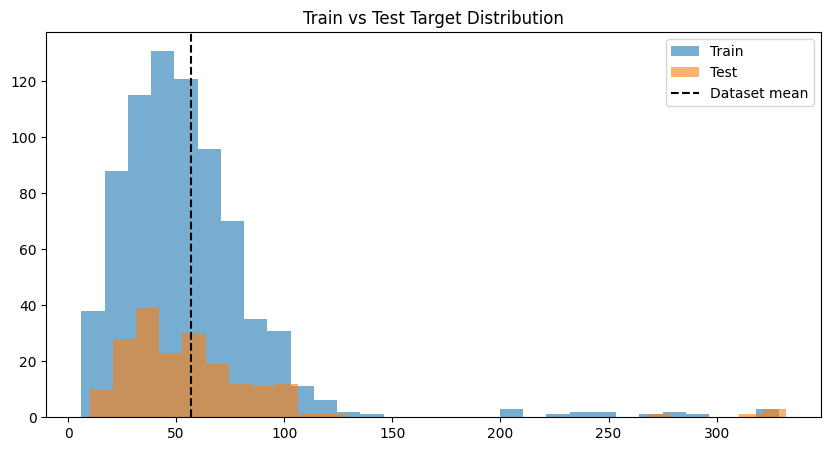

---- Target Distribution Check ----
Dataset mean/std: 56.87 / 40.47
Train mean/std:   56.03 / 38.19
Test mean/std:    60.23 / 48.47


In [6]:
# Target distribution comparison
plt.figure(figsize=(10,5))
plt.hist(y_train, bins=30, alpha=0.6, label='Train')
plt.hist(y_test, bins=30, alpha=0.6, label='Test')
plt.axvline(y.mean(), color='black', linestyle='--', label='Dataset mean')
plt.legend()
plt.title("Train vs Test Target Distribution")
plt.show()

print("---- Target Distribution Check ----")
print(f"Dataset mean/std: {y.mean():.2f} / {y.std():.2f}")
print(f"Train mean/std:   {y_train.mean():.2f} / {y_train.std():.2f}")
print(f"Test mean/std:    {y_test.mean():.2f} / {y_test.std():.2f}")

A random 80/20 split was used. The training and test sets show similar means and standard deviations relative to the full dataset, indicating a representative split. Minor differences are consistent with expected sampling variation.

# Train-Test EDA

In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 760 entries, 340 to 107
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       717 non-null    float64
 1   Time_of_Day            717 non-null    object 
 2   Day_of_Week            722 non-null    object 
 3   Passenger_Count        722 non-null    float64
 4   Traffic_Conditions     719 non-null    object 
 5   Weather                719 non-null    object 
 6   Base_Fare              727 non-null    float64
 7   Per_Km_Rate            723 non-null    float64
 8   Per_Minute_Rate        721 non-null    float64
 9   Trip_Duration_Minutes  731 non-null    float64
dtypes: float64(6), object(4)
memory usage: 65.3+ KB


## Summary Statistics

To confirm that the training dataset is representative of the full dataset, descriptive statistics were compared.

Across all numerical features, the training set maintains nearly identical means and standard deviations relative to the full dataset. Differences in central tendency are negligible (e.g., Trip_Distance_km mean difference = 0.41 km; Trip_Duration_Minutes mean difference = 0.14 minutes).

Across all categorical variables (Weather, Time_of_Day, Day_of_Week, Traffic_Conditions), differences in proportions were minimal, with the largest deviation below 1.5%.

This confirms that the random train-test split preserved the overall distribution of the data. 

In [8]:
display(dataset_df.describe().T)

X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Trip_Distance_km,901.0,27.190998,20.155134,1.2300,12.63000,25.8700,38.68000,146.067047
Passenger_Count,903.0,2.479513,1.100983,1.0000,2.00000,2.0000,3.00000,4.000000
Base_Fare,907.0,3.497100,0.866729,2.0100,2.73000,3.5100,4.23000,5.000000
Per_Km_Rate,907.0,1.229934,0.429958,0.5000,0.85000,1.2200,1.61000,2.000000
Per_Minute_Rate,902.0,0.293902,0.115404,0.1000,0.19000,0.2900,0.39000,0.500000
Trip_Duration_Minutes,905.0,62.044144,32.321578,5.0100,35.59000,61.5700,89.21000,119.840000
Trip_Price,951.0,56.874773,40.469791,6.1269,33.74265,50.0745,69.09935,332.043689


,count,mean,std,min,25%,50%,75%,max
Trip_Distance_km,717.0,26.784392,19.431155,1.25,12.630,25.42,38.360,139.476515
Passenger_Count,722.0,2.454294,1.105397,1.00,1.000,2.00,3.000,4.000000
Base_Fare,727.0,3.491994,0.872147,2.02,2.725,3.51,4.250,5.000000
Per_Km_Rate,723.0,1.223845,0.424401,0.50,0.850,1.21,1.580,2.000000
Per_Minute_Rate,721.0,0.294591,0.114413,0.10,0.190,0.29,0.390,0.500000
Trip_Duration_Minutes,731.0,61.900670,32.715146,5.01,34.840,61.64,89.605,119.820000


In [9]:
category_col = X_train.select_dtypes(include='object').columns

print('Full Dataset vs X_train')
for col in category_col:
    display(dataset_df[col].value_counts(normalize=True))
    display(X_train[col].value_counts(normalize=True))


Full Dataset vs X_train


Time_of_Day
Afternoon    0.389135
Morning      0.293792
Evening      0.218404
Night        0.098670
Name: proportion, dtype: float64

Time_of_Day
Afternoon    0.396095
Morning      0.295676
Evening      0.211994
Night        0.096234
Name: proportion, dtype: float64

Day_of_Week
Weekday    0.687293
Weekend    0.312707
Name: proportion, dtype: float64

Day_of_Week
Weekday    0.67867
Weekend    0.32133
Name: proportion, dtype: float64

Traffic_Conditions
Low       0.415094
Medium    0.394007
High      0.190899
Name: proportion, dtype: float64

Traffic_Conditions
Low       0.425591
Medium    0.379694
High      0.194715
Name: proportion, dtype: float64

Weather
Clear    0.700552
Rain     0.238674
Snow     0.060773
Name: proportion, dtype: float64

Weather
Clear    0.702364
Rain     0.230876
Snow     0.066759
Name: proportion, dtype: float64

## Visualizations

### Numerical Features

- **Trip_Distance_km** and **Trip_Price** are right-skewed, with several high-value outliers.
- **Trip_Price** shows a strong concentration between 40–60 with a long right tail extending beyond 200.
- **Trip_Duration_Minutes**, **Base_Fare**, **Per_Km_Rate**, and **Per_Minute_Rate** appear relatively uniformly distributed.
- No major distributional shifts were observed between the full dataset and the training subset.

### Categorical Features

- **Time_of_Day**, **Day_of_Week**, **Traffic_Conditions**, and **Weather** maintain similar category proportions in both datasets.
- Clear weather and weekday trips appear most common.
- Traffic conditions are reasonably balanced across Low, Medium, and High levels.

The distributions of the training dataset closely mirror those of the full dataset, indicating that the train-test split preserved the overall data structure.

Due to right-skewness observed in Trip_Price and Trip_Distance_km, transformations (e.g., log transformation) may be considered during modeling.

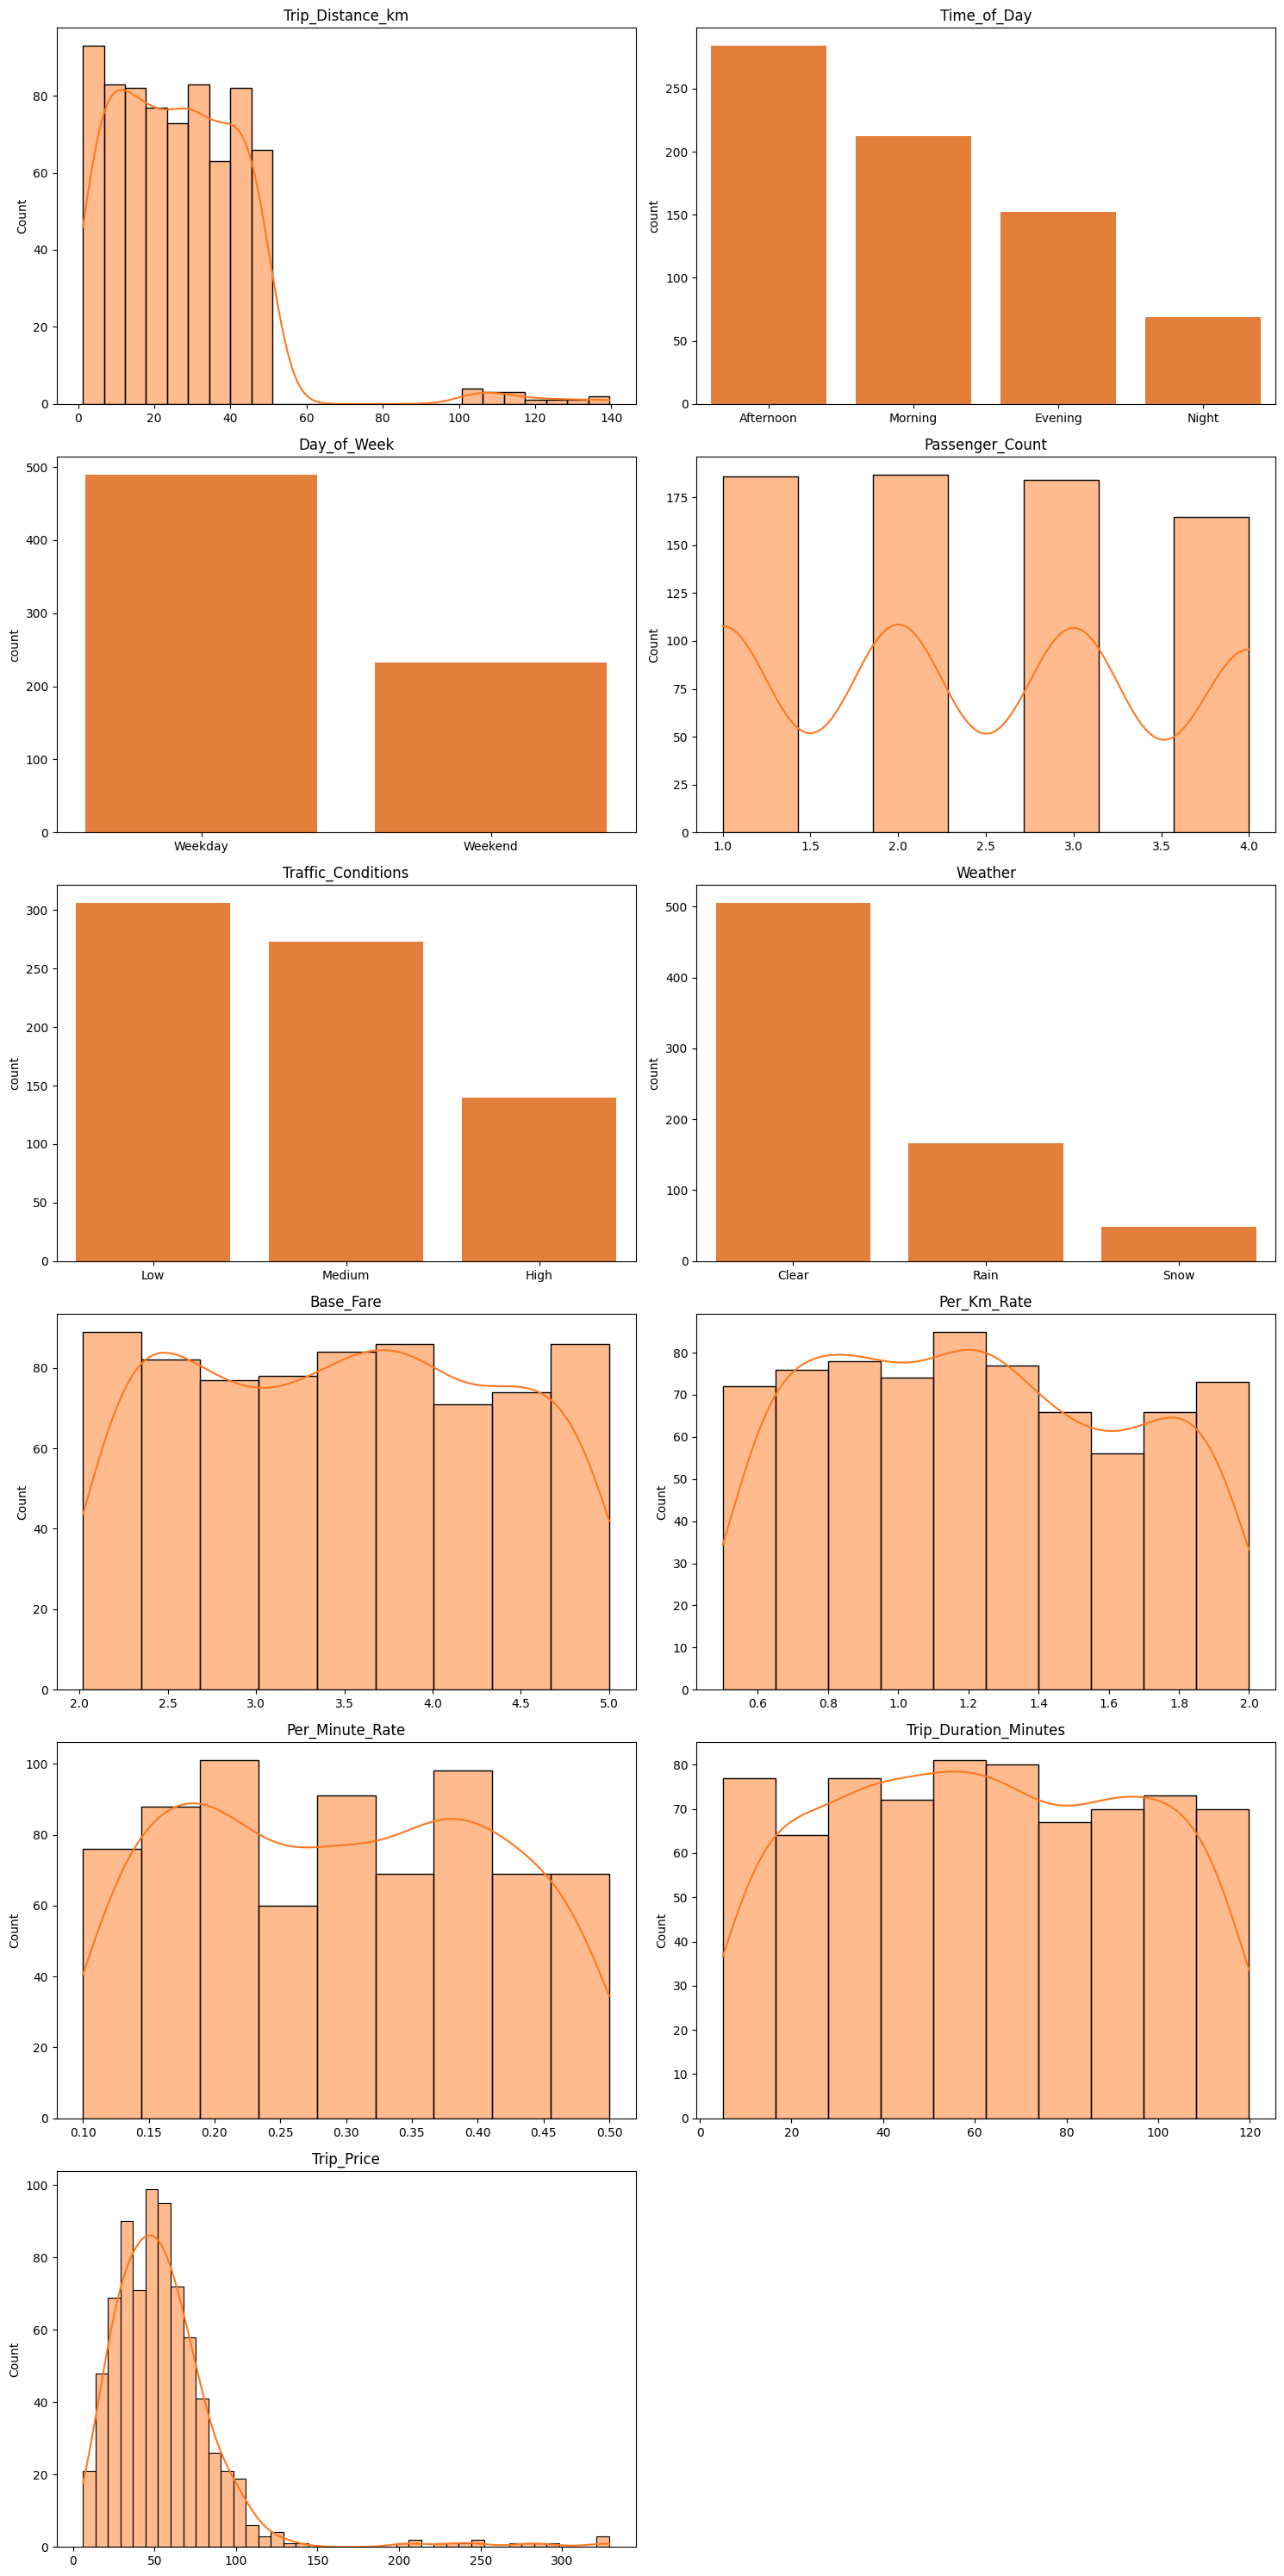

In [10]:
temp_eda_df = pd.concat([X_train, y_train], axis=1)

colors = ['#FF781F']

n_cols = 2
n_features = len(temp_eda_df.columns)
n_rows = math.ceil(n_features / n_cols)

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 5*n_rows))
ax = ax.flatten()

for i, col_name in enumerate(temp_eda_df.columns):

    if not pd.api.types.is_numeric_dtype(temp_eda_df[col_name]):

        counts = temp_eda_df[col_name].value_counts().reset_index()
        # counts.columns = [col_name, 'count']

        sns.barplot(
            data=counts,
            x=col_name,
            y='count',
            color=colors[0],
            ax=ax[i]
        )

    else:

        sns.histplot(
            temp_eda_df[col_name],
            kde=True,
            bins = 'fd', 
            color=colors[0],
            ax=ax[i]
        )

    ax[i].set_title(col_name)
    ax[i].set_xlabel('')

# Hide unused plots
for j in range(n_features, len(ax)):
    ax[j].axis('off')

plt.tight_layout()
plt.show()

# Scatter Plot Analysis: Independent Variables vs Trip Price

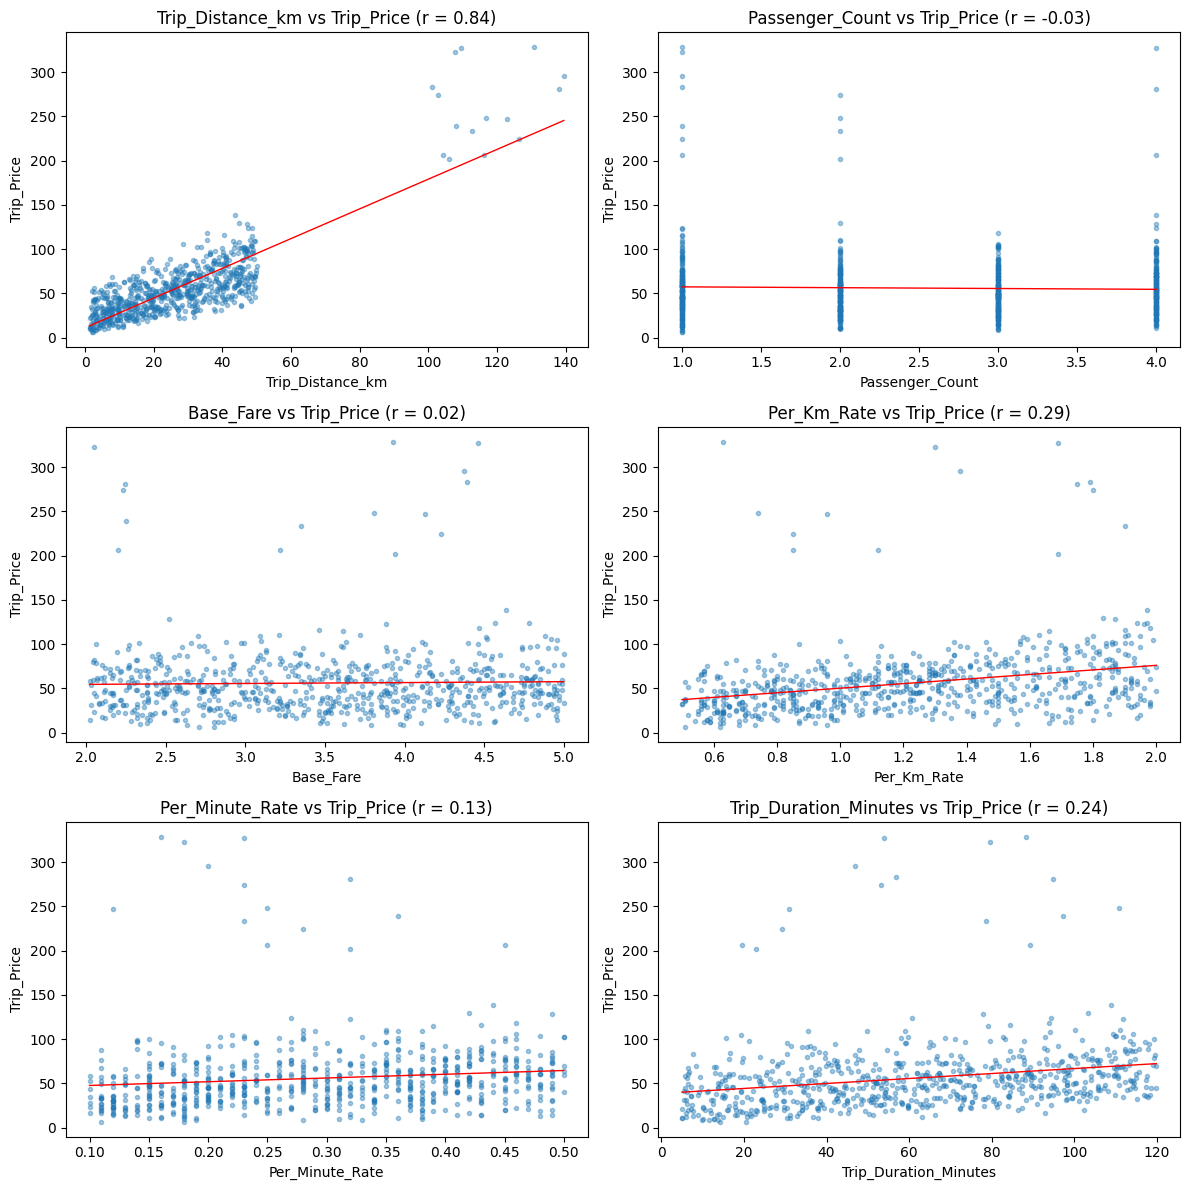

In [11]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))
ax = ax.flatten()

numerical_col = temp_eda_df.select_dtypes(include='number').drop('Trip_Price', axis=1).columns

for i, col in enumerate(numerical_col):

    corr = temp_eda_df[col].corr(temp_eda_df['Trip_Price'])
    
    sns.regplot(
        x=temp_eda_df[col],
        y=temp_eda_df['Trip_Price'],
        ax=ax[i],
        marker='.',
        scatter_kws={'alpha': 0.4},
        line_kws={'color': 'red', 'linewidth': 1},
        ci=None   
    )
    
    ax[i].set_title(f'{col} vs Trip_Price (r = {corr:.2f})')


plt.tight_layout()
plt.show()

### Relationship Between Features and Trip Price (Training Data)

The scatter plots above show the relationship between each independent variable and the target variable `Trip_Price` using the training dataset.

From the plots, **Trip_Distance_km shows the strongest positive correlation with Trip_Price (r ≈ 0.85)**. This indicates that trip price increases significantly as the distance increases, which aligns with typical taxi fare structures.

`Per_Km_Rate`, `Trip_Duration_Minutes`, and `Per_Minute_Rate` show **weak to moderate positive relationships** with trip price. These variables contribute to the overall fare but have less influence compared to trip distance.

On the other hand, `Passenger_Count` and `Base_Fare` show **little to no correlation** with trip price.

Overall, the plots suggest that **trip distance is the primary driver of trip price**, while other features provide additional but smaller contributions to the fare calculation.



# Data Preprocessing

In [23]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Low','Medium','High']]))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',handle_unknown='ignore'))
])

In [24]:
ordinal_features = ['Traffic_Conditions']
nominal_features = ['Weather', 'Time_of_Day', 'Day_of_Week']

preprocessor = ColumnTransformer([
    ('numerical', numeric_pipeline, numerical_col),
    ('ordinal', ordinal_pipeline, ordinal_features),
    ('nominal', nominal_pipeline, nominal_features)
],
remainder='passthrough'
)

In [16]:
X_train

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes
340,25.09,Morning,Weekend,2.0,Medium,Snow,3.25,1.87,0.33,70.95
571,39.40,NaN,Weekend,2.0,Medium,Rain,2.92,1.15,0.27,91.44
584,NaN,Night,Weekday,4.0,Low,Clear,2.73,1.47,0.37,42.88
115,43.70,NaN,Weekday,3.0,Low,Clear,4.52,1.59,0.28,114.29
81,31.54,Morning,Weekday,2.0,High,Clear,3.09,1.91,0.26,93.37
...,...,...,...,...,...,...,...,...,...,...
112,46.56,Morning,Weekday,3.0,Low,Clear,4.46,0.87,0.46,119.21
291,2.83,Morning,Weekday,1.0,Low,Snow,3.99,0.96,0.19,11.65
904,21.65,Evening,Weekday,3.0,High,Clear,2.18,1.05,NaN,24.22
461,32.81,Afternoon,Weekend,NaN,Low,Clear,4.84,NaN,0.23,64.74


In [25]:
X_processed = preprocessor.fit_transform(X_train)

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__")[1] for name in feature_names]

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
X_processed_df

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Traffic_Conditions,Weather_Rain,Weather_Snow,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend
0,25.09,2.0,3.25,1.87,0.33,70.95,1.0,0.0,1.0,0.0,1.0,0.0,1.0
1,39.40,2.0,2.92,1.15,0.27,91.44,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,25.42,4.0,2.73,1.47,0.37,42.88,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,43.70,3.0,4.52,1.59,0.28,114.29,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,31.54,2.0,3.09,1.91,0.26,93.37,2.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,46.56,3.0,4.46,0.87,0.46,119.21,0.0,0.0,0.0,0.0,1.0,0.0,0.0
756,2.83,1.0,3.99,0.96,0.19,11.65,0.0,0.0,1.0,0.0,1.0,0.0,0.0
757,21.65,3.0,2.18,1.05,0.29,24.22,2.0,0.0,0.0,1.0,0.0,0.0,0.0
758,32.81,2.0,4.84,1.21,0.23,64.74,0.0,0.0,0.0,0.0,0.0,0.0,1.0



### Data Preprocessing

Before training the machine learning model, the training dataset was preprocessed to handle missing values and prepare categorical variables.

Several features contained missing values. Numerical features such as trip distance, passenger count, fare rates, and trip duration were imputed using their median values to reduce the influence of outliers.

Categorical features including time of day, day of week, traffic conditions, and weather were imputed using the most frequent category (mode).

After handling missing values, categorical variables were encoded into numerical representations to allow them to be used by machine learning algorithms.

### **Missing Value Summary**

Out of 1000 total rows:

- Most features have 950 non-null values (50 missing, 5%)

- Target variable Trip_Price has 951 non-null values (49 missing, 4.9%)

This is a relatively small amount of missing data, so simple and safe imputation methods are appropriate.

Missing values in numerical features were filled using the median. 
Median imputation was chosen because it is robust to outliers and preserves the overall distribution better than mean imputation.

Missing values in categorical features were filled using the mode (most frequent value). 
This preserves valid category labels and avoids introducing artificial categories.

In [ ]:
dataset_df.info()
# dataset_df.isnull().sum()

In [ ]:
X = dataset_df.copy().drop('Trip_Price', axis=1)
y = dataset_df['Trip_Price']

## Feature Encoding

Categorical features were encoded using ColumnTransformer based on whether they have a natural order.

- **Traffic_Conditions** was encoded using OrdinalEncoder with the order:
  Low < Medium < High  
  This preserves the ordinal relationship.

- **Weather, Time_of_Day, and Day_of_Week** were encoded using OneHotEncoder since they do not have a natural order. The parameter `drop='first'` was used to prevent multicollinearity by setting a reference category.

- All remaining numeric features were left unchanged using `remainder='passthrough'`.

In [ ]:
ordinal_features = ['Traffic_Conditions']
nominal_features = ['Weather', 'Time_of_Day', 'Day_of_Week']

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[['Low','Medium','High']]), ordinal_features),
        ('nominal', OneHotEncoder(drop='first'), nominal_features)
    ],
    remainder='passthrough'
)

In [ ]:
X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__")[1] for name in feature_names]

X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
X_processed_df